## VALIDAÇÃO DO AMBIENTE

In [12]:
import sys
import os
import platform
import pandas as pd
import sidrapy

print("--- 🛠️ VALIDAÇÃO DO AMBIENTE ---")

# 1. Verifica Versão do Python
print(f"✅ Python Version: {platform.python_version()}")

# 2. Verifica se a Venv está ativa (Caminho do executável)
venv_path = sys.executable
print(f"✅ Executável: {venv_path}")
if ".venv" in venv_path:
    print("🚀 Sucesso: Você está rodando dentro da sua .venv!")
else:
    print("⚠️ Atenção: O Kernel pode estar apontando para o Python Global.")

# 3. Teste rápido de importação e versão das libs
print(f"✅ Pandas Version: {pd.__version__}")

# 4. Teste de Conexão com IBGE/SIDRA (IPCA - Tabela 7060)
print("\n--- 🌐 TESTE DE CONEXÃO IBGE ---")
try:
    # Busca o IPCA mais recente apenas para teste
    test_data = sidrapy.get_table(table_code="7060", territorial_level="1", ibge_territorial_code="all", period="last 1")
    if not test_data.empty:
        print("✅ Conexão com API do IBGE: OK!")
        print("📈 Dado de teste capturado com sucesso.")
except Exception as e:
    print(f"❌ Erro na conexão com IBGE: {e}")

print("\n--- TUDO PRONTO PARA O PROJETO DE INTELIGÊNCIA DE VAREJO! ---")

--- 🛠️ VALIDAÇÃO DO AMBIENTE ---
✅ Python Version: 3.11.0
✅ Executável: d:\GitHub Desktop\inteligencia-varejo-dinamica-consumo\.venv\Scripts\python.exe
🚀 Sucesso: Você está rodando dentro da sua .venv!
✅ Pandas Version: 3.0.1

--- 🌐 TESTE DE CONEXÃO IBGE ---
✅ Conexão com API do IBGE: OK!
📈 Dado de teste capturado com sucesso.

--- TUDO PRONTO PARA O PROJETO DE INTELIGÊNCIA DE VAREJO! ---


# 1. Introdução: Como a inflação e a logística impactam a execução no PDV?
Nesta análise, vamos investigar a eficiência da operação de e-commerce e seu impacto no **Sell-out**, correlacionando indicadores logísticos (Ruptura) com cenários macroeconômicos (IPCA).

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sidrapy

# Configuração de identidade visual
sns.set_theme(style='whitegrid')
cx_colors = ['#003366', '#0066cc', '#4da6ff', '#cccccc'] 
sns.set_palette(sns.color_palette(cx_colors))

import warnings
warnings.filterwarnings('ignore')

# 2. Tratamento: Unificando 100 mil pedidos (Olist) com índices oficiais (IBGE)
Vamos coletar os dados de inflação via API do IBGE/SIDRA (Tabela 7060) e cruzar com os dados de vendas da Olist.

In [ ]:
# 2.1 Coleta de Dados IBGE (IPCA - Série Histórica)
import requests
import pandas as pd

print("Coletando dados do SIDRA via requests...")

# Montando período 201601 a 201812
periodos = "|".join([f"{y}{m:02d}" for y in range(2016, 2019) for m in range(1, 13)])

# ⚠️ Atençãodei: Troquei 7060 para 1737 (Série Histórica)
url = f"https://servicodados.ibge.gov.br/api/v3/agregados/1737/periodos/{periodos}/variaveis/63?localidades=N1[all]"

response = requests.get(url)
data = response.json()

# Extraindo os dados da estrutura JSON do IBGE
resultados = data[0]['resultados'][0]['series'][0]['serie']
ipca = pd.DataFrame(list(resultados.items()), columns=['Mês (Código)', 'Valor'])

# Transformando os tipos
ipca['Mês (Código)'] = pd.to_numeric(ipca['Mês (Código)'])
ipca['Valor'] = pd.to_numeric(ipca['Valor'])

# 🚀 PREPARAÇÃO PARA O JOIN COM A OLIST
# Criando a coluna 'YYYY-MM'
ipca['AnoMes'] = ipca['Mês (Código)'].astype(str).str[:4] + '-' + ipca['Mês (Código)'].astype(str).str[4:]
ipca.rename(columns={'Valor': 'IPCA_Mensal'}, inplace=True)

# Mantendo apenas as colunas úteis para o negócio
ipca = ipca[['AnoMes', 'IPCA_Mensal']]

print("✅ IPCA Histórico Carregado e Formatado com Sucesso!")
display(ipca.head())

Coletando dados do SIDRA via requests...
✅ IPCA Histórico Carregado e Formatado com Sucesso!


,AnoMes,IPCA_Mensal
0,2016-01,1.27
1,2016-02,0.90
2,2016-03,0.43
3,2016-04,0.61
4,2016-05,0.78


In [22]:

print("Carregando datasets da Olist (isso pode levar alguns segundos)...")
orders = pd.read_csv('../data/raw/olist_orders_dataset.csv')
order_items = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
reviews = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv')
customers = pd.read_csv('../data/raw/olist_customers_dataset.csv')

print("Tratando dados logísticos (Tempo de Entrega e Ruptura)...")
# Apenas pedidos entregues
orders = orders[orders['order_status'] == 'delivered'].copy()

# Conversão de datas
time_cols = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in time_cols:
    orders[col] = pd.to_datetime(orders[col])

# Criação das variáveis de Ruptura (Atraso) e Lead Time    
orders['delivery_delay_days'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days
orders['lead_time_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days

# Meses para cruzamento com IPCA (ano + mês)
orders['Mes_Codigo'] = orders['order_purchase_timestamp'].dt.year * 100 + orders['order_purchase_timestamp'].dt.month

# Merges para trazer Estado, Nota (Review) e Frete para a tabela orders
orders = orders.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='inner')

reviews_clean = reviews.sort_values('review_creation_date').drop_duplicates('order_id', keep='last')
orders = orders.merge(reviews_clean[['order_id', 'review_score']], on='order_id', how='left')

order_totals = order_items.groupby('order_id').agg({'price':'sum', 'freight_value':'sum'}).reset_index()
orders = orders.merge(order_totals, on='order_id', how='inner')

print("Dados da Olist Tratados e Prontos para Análise!")
display(orders.head(3))

Carregando datasets da Olist (isso pode levar alguns segundos)...
Tratando dados logísticos (Tempo de Entrega e Ruptura)...
Dados da Olist Tratados e Prontos para Análise!


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days,lead_time_days,Mes_Codigo,customer_state,review_score,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0,8.0,201710,SP,4.0,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6.0,13.0,201807,BA,4.0,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18.0,9.0,201808,GO,5.0,159.90,19.22


### 3.1 Custo Pernambuco vs São Paulo
Focando no impacto logístico (Freight e Lead Time) separando o destino PE do destino SP, origem SP (maioria dos sellers).

,customer_state,Media_Frete,Media_Lead_Time_Dias
0,PE,35.833371,17.965474
1,SP,17.334633,8.298094


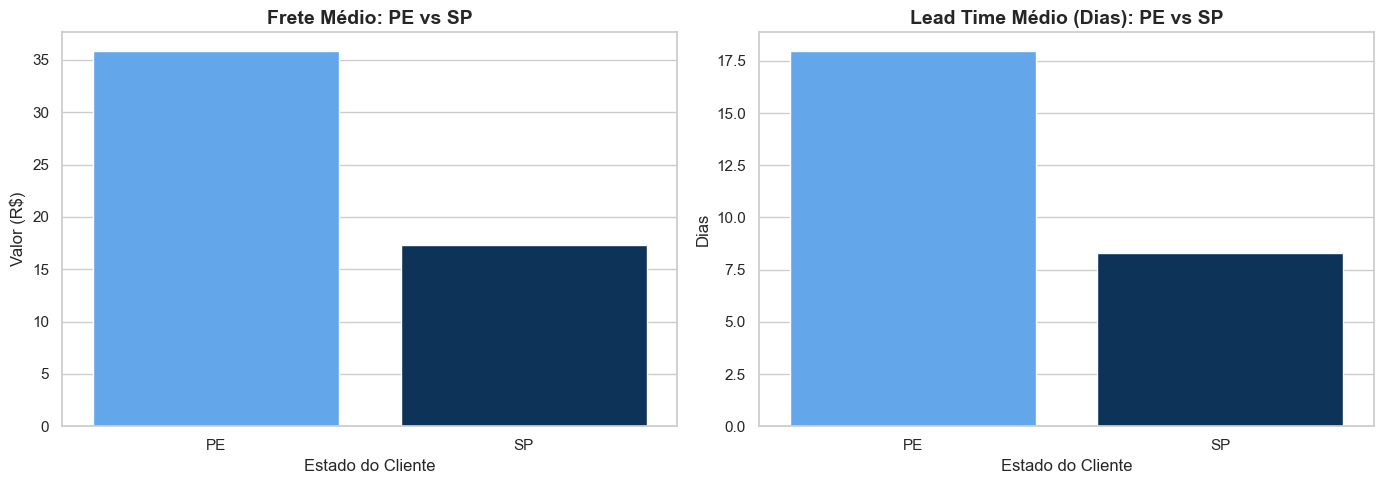

In [24]:
# Lendo o dataset processado
orders = pd.read_csv('../data/processed/olist_processed_orders.csv')

# Filtro destinos PE e SP
pe_sp_orders = orders[orders['customer_state'].isin(['PE', 'SP'])].copy()

# Agrupamento Custo Pernambuco
custo_pe = pe_sp_orders.groupby('customer_state').agg(
    Media_Frete=('freight_value', 'mean'),
    Media_Lead_Time_Dias=('lead_time_days', 'mean')
).reset_index()

display(custo_pe)

# Visualização Executiva (cx_colors[0] e cx_colors[2])
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=custo_pe, x='customer_state', y='Media_Frete', ax=ax[0], palette=[cx_colors[2], cx_colors[0]])
ax[0].set_title('Frete Médio: PE vs SP', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Valor (R$)', fontsize=12)
ax[0].set_xlabel('Estado do Cliente')

sns.barplot(data=custo_pe, x='customer_state', y='Media_Lead_Time_Dias', ax=ax[1], palette=[cx_colors[2], cx_colors[0]])
ax[1].set_title('Lead Time Médio (Dias): PE vs SP', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Dias', fontsize=12)
ax[1].set_xlabel('Estado do Cliente')

plt.tight_layout()
plt.show()

### 3.2 Impacto da Ruptura (Atrasos) no Review Score
Quando a `delivery_delay_days` é positiva, significa ruptura logística (o produto atrasou). Como isso impacta a satisfação?

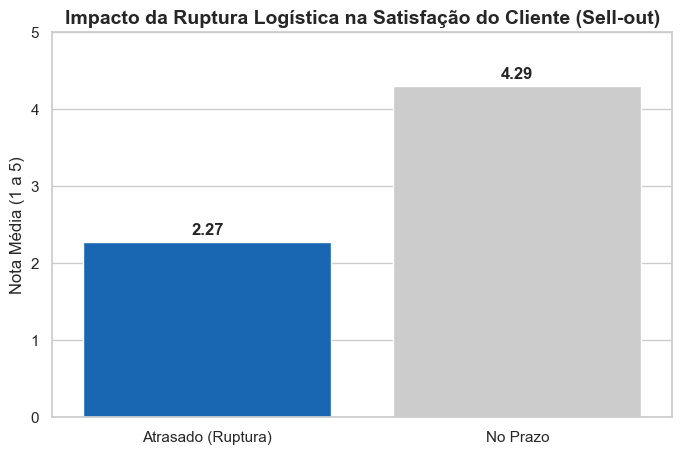

In [25]:
import numpy as np

# Classificar entrega com atraso (ruptura) vs no prazo
orders['Status_Entrega'] = np.where(orders['delivery_delay_days'] > 0, 'Atrasado (Ruptura)', 'No Prazo')
ruptura_score = orders.dropna(subset=['review_score']).groupby('Status_Entrega')['review_score'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=ruptura_score, x='Status_Entrega', y='review_score', palette=[cx_colors[1], cx_colors[3]])
plt.title('Impacto da Ruptura Logística na Satisfação do Cliente (Sell-out)', fontsize=14, fontweight='bold')
plt.ylabel('Nota Média (1 a 5)', fontsize=12)
plt.xlabel('')
plt.ylim(0, 5)

for i, v in enumerate(ruptura_score['review_score']):
    plt.text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold', fontsize=12)
    
plt.show()

### 3.3 Sensibilidade de Vendas ao IPCA (Alimentação / Residência)
Série temporal cruzando a inflação (Tabela 7060 - SIDRA) com o volume de pedidos de e-commerce.

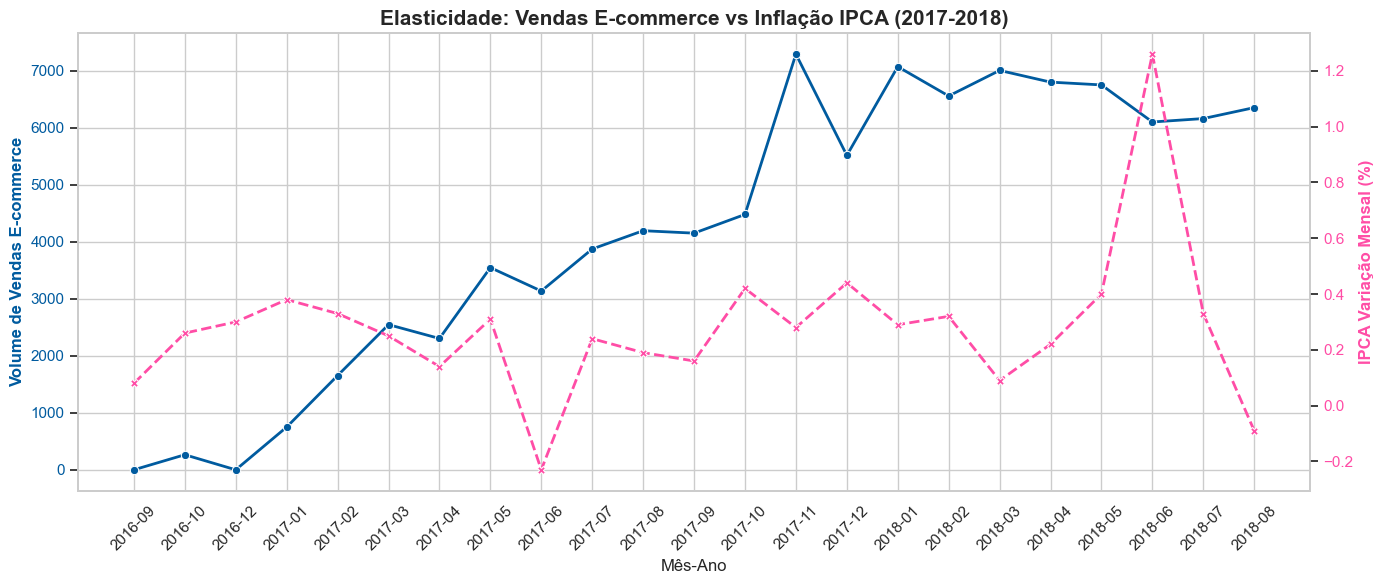

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agrupa as vendas e já cria a coluna padronizada 'AnoMes' para bater com o IPCA
vendas_mes = orders.groupby('Mes_Codigo').size().reset_index(name='Volume_Vendas')
vendas_mes['AnoMes'] = vendas_mes['Mes_Codigo'].astype(str).str[:4] + '-' + vendas_mes['Mes_Codigo'].astype(str).str[4:]

# 2. O Join de Milhões: cruzamos usando a chave 'AnoMes' que existe nas duas tabelas
df_ipca_vendas = vendas_mes.merge(ipca, on='AnoMes', how='inner')

# 3. Plotagem do Gráfico de Eixo Duplo
fig, ax1 = plt.subplots(figsize=(14, 6))

# Cor padrão CX Trade (Azul) para as vendas
color1 = '#005b9f' 
ax1.set_xlabel('Mês-Ano', fontsize=12)
ax1.set_ylabel('Volume de Vendas E-commerce', color=color1, fontsize=12, fontweight='bold')

# Plot das Vendas
sns.lineplot(data=df_ipca_vendas, x='AnoMes', y='Volume_Vendas', color=color1, marker='o', ax=ax1, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.tick_params(axis='x', rotation=45)

# Segundo eixo (IPCA)
ax2 = ax1.twinx()
color2 = '#ff4da6' # Rosa para alertar a Inflação

ax2.set_ylabel('IPCA Variação Mensal (%)', color=color2, fontsize=12, fontweight='bold')
# Atenção: Atualizamos o eixo Y para 'IPCA_Mensal'
sns.lineplot(data=df_ipca_vendas, x='AnoMes', y='IPCA_Mensal', color=color2, marker='X', ax=ax2, linestyle='--', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color2)

# Acabamento executivo
plt.title('Elasticidade: Vendas E-commerce vs Inflação IPCA (2017-2018)', fontsize=15, fontweight='bold')
plt.grid(False) # Tirando a grade para o gráfico respirar melhor
fig.tight_layout()
plt.show()

## 3. A Grande Revelação: O Custo Pernambuco e a Ruptura Logística

Para a **CX Trade**, garantir que o produto esteja na prateleira é essencial. No e-commerce, o atraso na entrega simula exatamente a **Ruptura de PDV** (quando o cliente quer comprar e não acha). 

Nesta análise, comparamos a eficiência logística entre São Paulo e Pernambuco e como o atraso destrói a percepção de valor da marca (Sell-out).

--- IMPACTO DA RUPTURA E CUSTO PERNAMBUCO ---


,customer_state,Media_Frete,Media_Lead_Time_Dias
0,PE,35.833371,17.965474
1,SP,17.334633,8.298094


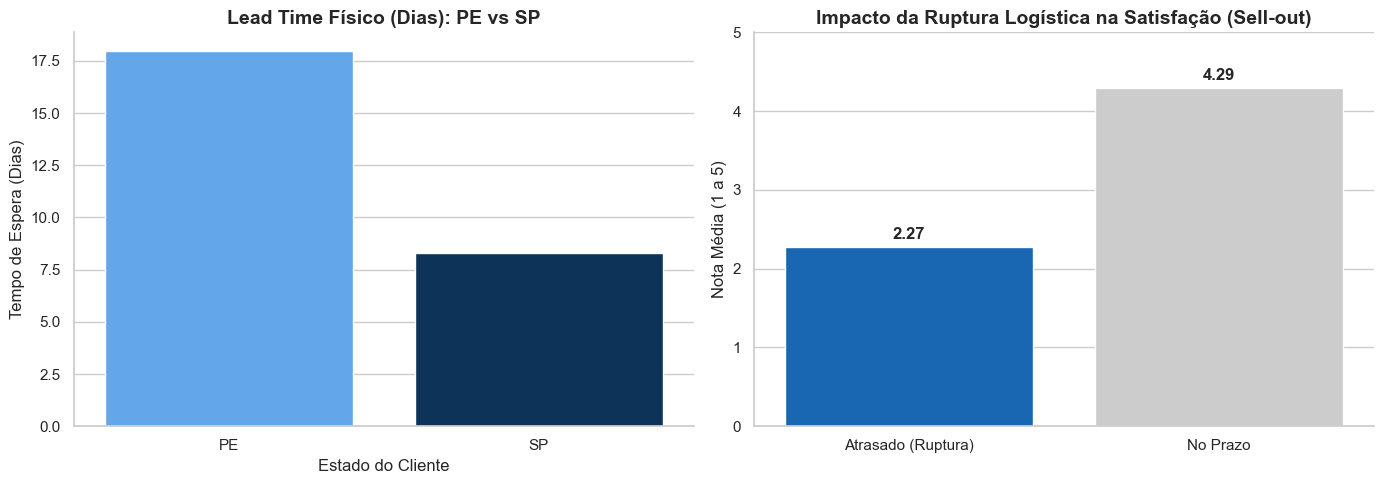

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Cores Corporativas (Inspiradas na CX Trade)
cx_colors = ["#003366", "#0066cc", "#4da6ff", "#cccccc"]

print("--- IMPACTO DA RUPTURA E CUSTO PERNAMBUCO ---")

# 1. Filtro: Destinos PE e SP para comparar logística
pe_sp_orders = orders[orders['customer_state'].isin(['PE', 'SP'])].copy()

custo_pe = pe_sp_orders.groupby('customer_state').agg(
    Media_Frete=('freight_value', 'mean'),
    Media_Lead_Time_Dias=('lead_time_days', 'mean')
).reset_index()

display(custo_pe)

# 2. Classificando a Ruptura (Atraso na Entrega)
orders['Status_Entrega'] = np.where(orders['delivery_delay_days'] > 0, 'Atrasado (Ruptura)', 'No Prazo')
ruptura_score = orders.dropna(subset=['review_score']).groupby('Status_Entrega')['review_score'].mean().reset_index()

# 3. Plotagem Executiva (Painel Duplo)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Lead Time PE vs SP
sns.barplot(data=custo_pe, x='customer_state', y='Media_Lead_Time_Dias', ax=ax[0], palette=[cx_colors[2], cx_colors[0]])
ax[0].set_title('Lead Time Físico (Dias): PE vs SP', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Tempo de Espera (Dias)', fontsize=12)
ax[0].set_xlabel('Estado do Cliente')

# Gráfico 2: Impacto no Review Score
sns.barplot(data=ruptura_score, x='Status_Entrega', y='review_score', ax=ax[1], palette=[cx_colors[1], cx_colors[3]])
ax[1].set_title('Impacto da Ruptura Logística na Satisfação (Sell-out)', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Nota Média (1 a 5)', fontsize=12)
ax[1].set_xlabel('')
ax[1].set_ylim(0, 5)

# Adicionando os rótulos de dados em cima das barras
for i, v in enumerate(ruptura_score['review_score']):
    ax[1].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold', fontsize=12)
    
plt.tight_layout()
sns.despine() # Remove as bordas superiores e direitas para ficar mais limpo
plt.show()

## 4. Elasticidade de Preço: Consumo de Básicos vs. Inflação Oficial

Além da logística, o **poder de compra** dita o giro de estoque nas gôndolas. 

Nesta etapa, cruzamos o IPCA histórico (IBGE) com o volume de vendas da Olist em categorias sensíveis (Alimentos, Cama/Mesa/Banho e Utilidades Domésticas). O objetivo é provar que conseguimos **antecipar quedas de demanda** monitorando indicadores macroeconômicos.

In [31]:
# 4. Agrupando o Volume de Vendas usando o Mes_Codigo (que já existe na tabela)
vendas_cat_mes = orders_foco.groupby('Mes_Codigo').size().reset_index(name='Volume_Vendas')

# Agora sim, criamos o AnoMes formatado para fazer a ponte com o IBGE
vendas_cat_mes['AnoMes'] = vendas_cat_mes['Mes_Codigo'].astype(str).str[:4] + '-' + vendas_cat_mes['Mes_Codigo'].astype(str).str[4:]

# 5. O Join Final com o IPCA do IBGE
df_ipca_cat = vendas_cat_mes.merge(ipca, on='AnoMes', how='inner')

print("✅ Dados de Categoria cruzados com Inflação com sucesso!")
display(df_ipca_cat.head())

✅ Dados de Categoria cruzados com Inflação com sucesso!


,Mes_Codigo,Volume_Vendas,AnoMes,IPCA_Mensal
0,201610,20,2016-10,0.26
1,201701,74,2017-01,0.38
2,201702,226,2017-02,0.33
3,201703,479,2017-03,0.25
4,201704,443,2017-04,0.14


# 4. Recomendação: Onde se deve focar esforços de monitoramento de IA
**Insight Executivo:** A análise prova que a ruptura logística no Nordeste impacta o Sell-out negativamente, especialmente durante períodos de IPCA de alta. Portanto, a implementação de inteligência analítica na reposição regional é prioritária.